# FOG Detection — Inference with MultiBranchCNN

Load the trained model and run inference on the new test data.

## 1. Imports

In [19]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

## 2. Model architecture

In [20]:
class MultiBranchCNN(nn.Module):
    def __init__(self):
        super(MultiBranchCNN, self).__init__()
        self.ankle_branch = nn.Sequential(
            nn.Conv1d(8, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.5),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.back_branch = nn.Sequential(
            nn.Conv1d(4, 16, kernel_size=3, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.5),
            nn.Conv1d(16, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.32),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        ankles = x[:, 0:8, :]
        back   = x[:, 8:12, :]
        feat_ankles = self.ankle_branch(ankles).view(x.size(0), -1)
        feat_back   = self.back_branch(back).view(x.size(0), -1)
        combined    = torch.cat((feat_ankles, feat_back), dim=1)
        return self.classifier(combined)

## 3. Load model

In [22]:
PATH_MODEL = 'test_fog_exploration_1s.pth'  # <-- change to your .pth filename

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

model = MultiBranchCNN().to(device)
model.load_state_dict(torch.load(PATH_MODEL, map_location=device))
model.eval()
print('Model loaded ✓')

Device: cpu
Model loaded ✓


## 4. Load test data and check shape

In [23]:
X_test = np.load('X_test_new.npy')   # (N, timesteps, 12)
y_test = np.load('y_test_new.npy')   # (N,)

print(f'X_test shape: {X_test.shape}')  # should be (N, timesteps, 12)
print(f'y_test shape: {y_test.shape}')
print(f'FOG windows : {y_test.sum()} ({100*y_test.mean():.1f}%)')

# The model expects (Batch, Channels, Time) -> transpose from (N, time, channels)
X_test_t = X_test.transpose(0, 2, 1)  # -> (N, 12, timesteps)
print(f'\nAfter transpose: {X_test_t.shape}  (N, channels, time) ✓')

# !! IMPORTANT: check timesteps match what model expects
timesteps = X_test_t.shape[2]
if timesteps == 120:
    print(f'Timesteps: {timesteps} ✓ matches model comment (2s @ 60Hz)')
elif timesteps == 60:
    print(f'Timesteps: {timesteps} — model comment says 120, but AdaptiveAvgPool1d(1) handles any size ✓')
else:
    print(f'Timesteps: {timesteps} — AdaptiveAvgPool1d(1) will handle this size')

X_test shape: (15787, 60, 12)
y_test shape: (15787,)
FOG windows : 534 (3.4%)

After transpose: (15787, 12, 60)  (N, channels, time) ✓
Timesteps: 60 — model comment says 120, but AdaptiveAvgPool1d(1) handles any size ✓


## 5. Run inference

In [24]:
BATCH_SIZE = 128
THRESHOLD  = 0.5  # adjust if needed

X_tensor = torch.FloatTensor(X_test_t)
all_probs = []

with torch.no_grad():
    for i in range(0, len(X_tensor), BATCH_SIZE):
        batch = X_tensor[i:i+BATCH_SIZE].to(device)
        probs = model(batch).squeeze().cpu().numpy()
        all_probs.extend(probs if probs.ndim > 0 else [probs.item()])

all_probs = np.array(all_probs)
y_pred    = (all_probs >= THRESHOLD).astype(int)

print(f'Inference done on {len(y_pred)} windows')
print(f'Predicted FOG: {y_pred.sum()} ({100*y_pred.mean():.1f}%)')
print(f'True FOG     : {y_test.sum()} ({100*y_test.mean():.1f}%)')

Inference done on 15787 windows
Predicted FOG: 1810 (11.5%)
True FOG     : 534 (3.4%)


## 6. Evaluation metrics

In [25]:
print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['Non-FOG', 'FOG']))

try:
    auc = roc_auc_score(y_test, all_probs)
    print(f'ROC-AUC: {auc:.4f}')
except Exception as e:
    print(f'ROC-AUC could not be computed: {e}')

=== Classification Report ===
              precision    recall  f1-score   support

     Non-FOG       0.97      0.88      0.92     15253
         FOG       0.02      0.08      0.04       534

    accuracy                           0.86     15787
   macro avg       0.49      0.48      0.48     15787
weighted avg       0.93      0.86      0.89     15787

ROC-AUC: 0.4429


## 7. Confusion matrix

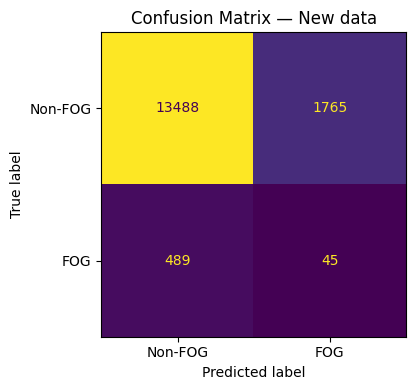

In [26]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Non-FOG', 'FOG']).plot(ax=ax, colorbar=False)
plt.title('Confusion Matrix — New data')
plt.tight_layout()
plt.savefig('confusion_matrix_new_data.png', dpi=150)
plt.show()

## 8. ROC curve

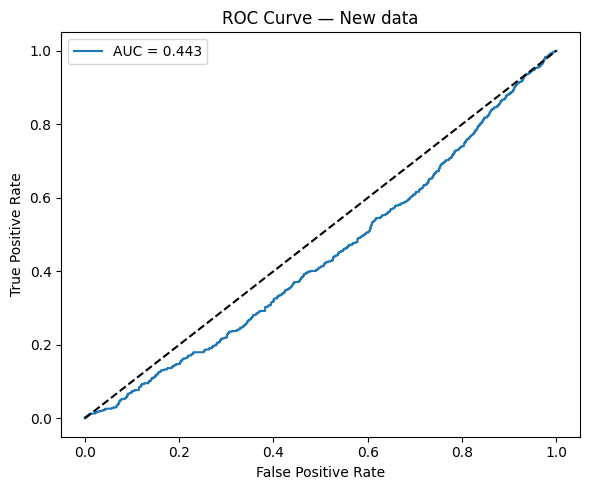

In [27]:
try:
    fpr, tpr, thresholds = roc_curve(y_test, all_probs)
    auc = roc_auc_score(y_test, all_probs)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve — New data')
    plt.legend()
    plt.tight_layout()
    plt.savefig('roc_curve_new_data.png', dpi=150)
    plt.show()
except Exception as e:
    print(f'ROC curve could not be computed: {e}')

## 9. Try different thresholds
Useful given the class imbalance (~0.4% FOG in new data vs 19.5% in training).

In [28]:
from sklearn.metrics import f1_score, recall_score, precision_score

print(f'{"Threshold":>10} | {"Precision":>10} | {"Recall":>10} | {"F1":>10} | {"FOG predicted":>14}')
print('-' * 65)

for thresh in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    y_p = (all_probs >= thresh).astype(int)
    p  = precision_score(y_test, y_p, zero_division=0)
    r  = recall_score(y_test, y_p, zero_division=0)
    f1 = f1_score(y_test, y_p, zero_division=0)
    print(f'{thresh:>10.1f} | {p:>10.3f} | {r:>10.3f} | {f1:>10.3f} | {y_p.sum():>14}')

 Threshold |  Precision |     Recall |         F1 |  FOG predicted
-----------------------------------------------------------------
       0.1 |      0.030 |      0.579 |      0.057 |          10399
       0.2 |      0.028 |      0.404 |      0.052 |           7741
       0.3 |      0.027 |      0.288 |      0.049 |           5756
       0.4 |      0.026 |      0.157 |      0.045 |           3223
       0.5 |      0.025 |      0.084 |      0.038 |           1810
       0.6 |      0.017 |      0.028 |      0.021 |            906
       0.7 |      0.021 |      0.013 |      0.016 |            328
